# **Import Libraries**

In [87]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score,
                             precision_score,
                             recall_score,
                             classification_report,
                             f1_score,
                             confusion_matrix)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

print("Libraries Loaded✅")

Libraries Loaded✅


# **Data Exploration**

## *LOAD THE DATA*

In [88]:
File_path = input('Enter the File Path: ').replace('\\','\\') 
df = pd.read_csv(File_path)
print('Data Loaded👍')

Data Loaded👍


## *EXPLORATION*

In [89]:
print(f"The Row in the data is {df.shape[0]} and column is {df.shape[1]}")

The Row in the data is 634 and column is 8


In [90]:
print("First 5 Rows")
df.head()

First 5 Rows


,age,bmi,blood_sugar,blood_pressure,cholesterol,is_smoker,family_history,has_disease
0,50.0,42.2,117.1,102.0,227.0,0.0,0.0,1
1,42.0,27.9,111.7,82.0,142.0,0.0,0.0,0
2,56.0,31.2,73.2,136.0,181.0,1.0,0.0,1
3,38.0,29.8,247.5,123.0,132.0,0.0,1.0,1
4,71.0,29.0,271.3,68.0,256.0,1.0,1.0,1


In [91]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 634 entries, 0 to 633
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             634 non-null    float64
 1   bmi             634 non-null    str    
 2   blood_sugar     614 non-null    float64
 3   blood_pressure  634 non-null    float64
 4   cholesterol     613 non-null    float64
 5   is_smoker       634 non-null    float64
 6   family_history  634 non-null    float64
 7   has_disease     634 non-null    int64  
dtypes: float64(6), int64(1), str(1)
memory usage: 39.8 KB


In [92]:
df.describe()

,age,blood_sugar,blood_pressure,cholesterol,is_smoker,family_history,has_disease
count,634.000000,614.000000,634.000000,613.000000,634.000000,634.000000,634.000000
mean,51.790221,188.406515,97.981073,218.185971,0.351735,0.370662,0.802839
std,16.295606,71.793044,23.165036,58.519574,0.477889,0.483364,0.398169
min,25.000000,71.300000,-20.000000,120.000000,0.000000,0.000000,0.000000
25%,38.000000,131.875000,79.000000,167.000000,0.000000,0.000000,1.000000
50%,51.000000,189.350000,97.000000,220.000000,0.000000,0.000000,1.000000
75%,65.000000,243.925000,117.000000,268.000000,1.000000,1.000000,1.000000
max,150.000000,900.000000,139.000000,318.000000,1.000000,1.000000,1.000000


In [93]:
print(f"The NaN Values in the Data is: ")
df.isna().sum()

The NaN Values in the Data is: 


age                0
bmi                0
blood_sugar       20
blood_pressure     0
cholesterol       21
is_smoker          0
family_history     0
has_disease        0
dtype: int64

In [94]:
print(f"The Duplicates Values in the Data is: {df.duplicated().sum()}")

The Duplicates Values in the Data is: 14


# **Data Cleaning**

In [95]:
df_copy = df.copy()

**DataType**

In [96]:
df_copy['bmi'] = df_copy['bmi'].replace('_err','',regex=True).astype('float')

**Impossible Values**

In [97]:
df_copy.loc[df_copy['age']<=0,'age'] = np.nan
df_copy.loc[df_copy['age']>=80,'age'] = np.nan

**Outliers**

In [98]:
columns = df_copy.select_dtypes(include='number').columns.tolist()

# remove target column properly
columns.remove('has_disease')

for col in columns:
    Q1 = df_copy[col].quantile(0.25)
    Q3 = df_copy[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df_copy.loc[df_copy[col] < lower, col] = np.nan
    df_copy.loc[df_copy[col] > upper, col] = np.nan

print("Outliers Handled ✅")

Outliers Handled ✅


**Duplicates**

In [99]:
print('Duplicates in the data is:',df_copy.duplicated().sum())
df_copy.drop_duplicates(inplace=True)
print('Duplicates in the data after cleaning is:',df_copy.duplicated().sum())
print('Data With no Disease record is:',df_copy['has_disease'].isna().sum())
df_copy.dropna(inplace=True,subset='has_disease')
print('Data With Disease record only is:',df_copy['has_disease'].isna().sum())

Duplicates in the data is: 14
Duplicates in the data after cleaning is: 0
Data With no Disease record is: 0
Data With Disease record only is: 0


**NaN values**

In [100]:
print('NaN Values Before: \n')
print(df_copy.isna().sum())
columns = df_copy.columns.tolist()
for col in columns:
    df_copy[col] = df_copy[col].fillna(round(df_copy[col].median(),2))
print('NaN Values After: \n')
print(df_copy.isna().sum())

NaN Values Before: 

age                1
bmi                1
blood_sugar       21
blood_pressure     1
cholesterol       20
is_smoker          0
family_history     0
has_disease        0
dtype: int64
NaN Values After: 

age               0
bmi               0
blood_sugar       0
blood_pressure    0
cholesterol       0
is_smoker         0
family_history    0
has_disease       0
dtype: int64


# **Data preperation**

In [101]:
X = df_copy[['age',
             'bmi',
             'blood_sugar',
             'blood_pressure',
             'cholesterol',
             'is_smoker',
             'family_history']]

y = df_copy['has_disease']

print(f"X shape: {X.shape}")
print(f'y Shape: {y.shape}')

X shape: (620, 7)
y Shape: (620,)


In [102]:
X_train,X_test,y_train,y_test = train_test_split(X,y,train_size=0.8,random_state=42,stratify=y)


print(f"X_train shape: {X_train.shape}")
print(f'y_train Shape: {y_train.shape}')
print(f'X_test Shape: {X_test.shape}')
print(f'y_test Shape: {y_test.shape}')

X_train shape: (496, 7)
y_train Shape: (496,)
X_test Shape: (124, 7)
y_test Shape: (124,)


# **Model**

## *Train*

In [103]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=1000))
])

pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not wo

## *Test*

In [104]:
y_pred = pipeline.predict(X_test)

y_prob = pipeline.predict_proba(X_test)[:,1]

comparison = pd.DataFrame({
    'Actual':      y_test.values,
    'Predicted':   y_pred,
    'Probability': y_prob.round(3)
})
print(comparison.head(10))

   Actual  Predicted  Probability
0       0          1        0.810
1       1          1        0.988
2       1          1        1.000
3       1          1        1.000
4       1          1        0.842
5       1          1        0.999
6       1          1        1.000
7       1          1        0.848
8       1          1        0.994
9       1          1        0.967


## *Evaluation*

In [105]:
print("Accuracy:", round(accuracy_score(y_test, y_pred),3))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.911
[[15 10]
 [ 1 98]]
              precision    recall  f1-score   support

           0       0.94      0.60      0.73        25
           1       0.91      0.99      0.95        99

    accuracy                           0.91       124
   macro avg       0.92      0.79      0.84       124
weighted avg       0.91      0.91      0.90       124



# **Charts**

**Confussion matrix**

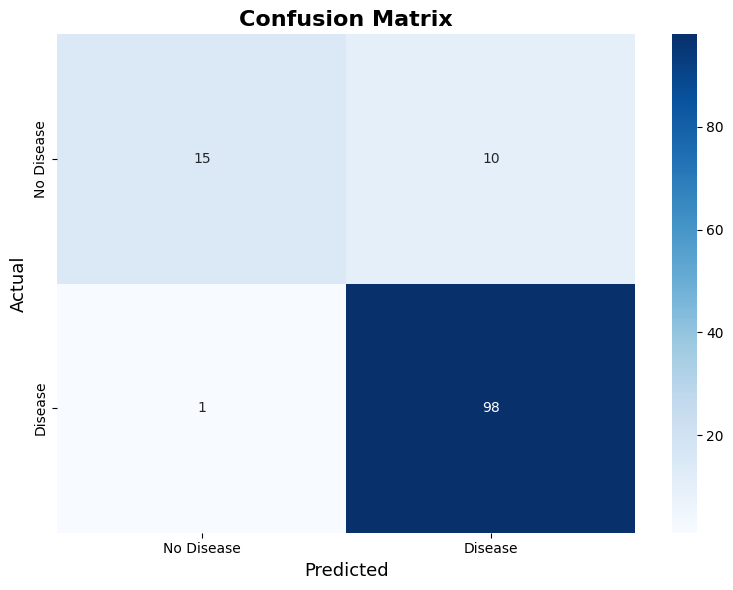

In [106]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Disease', 'Disease'],
            yticklabels=['No Disease', 'Disease'])
plt.xlabel('Predicted', fontsize=13)
plt.ylabel('Actual', fontsize=13)
plt.title('Confusion Matrix', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

**All in One**

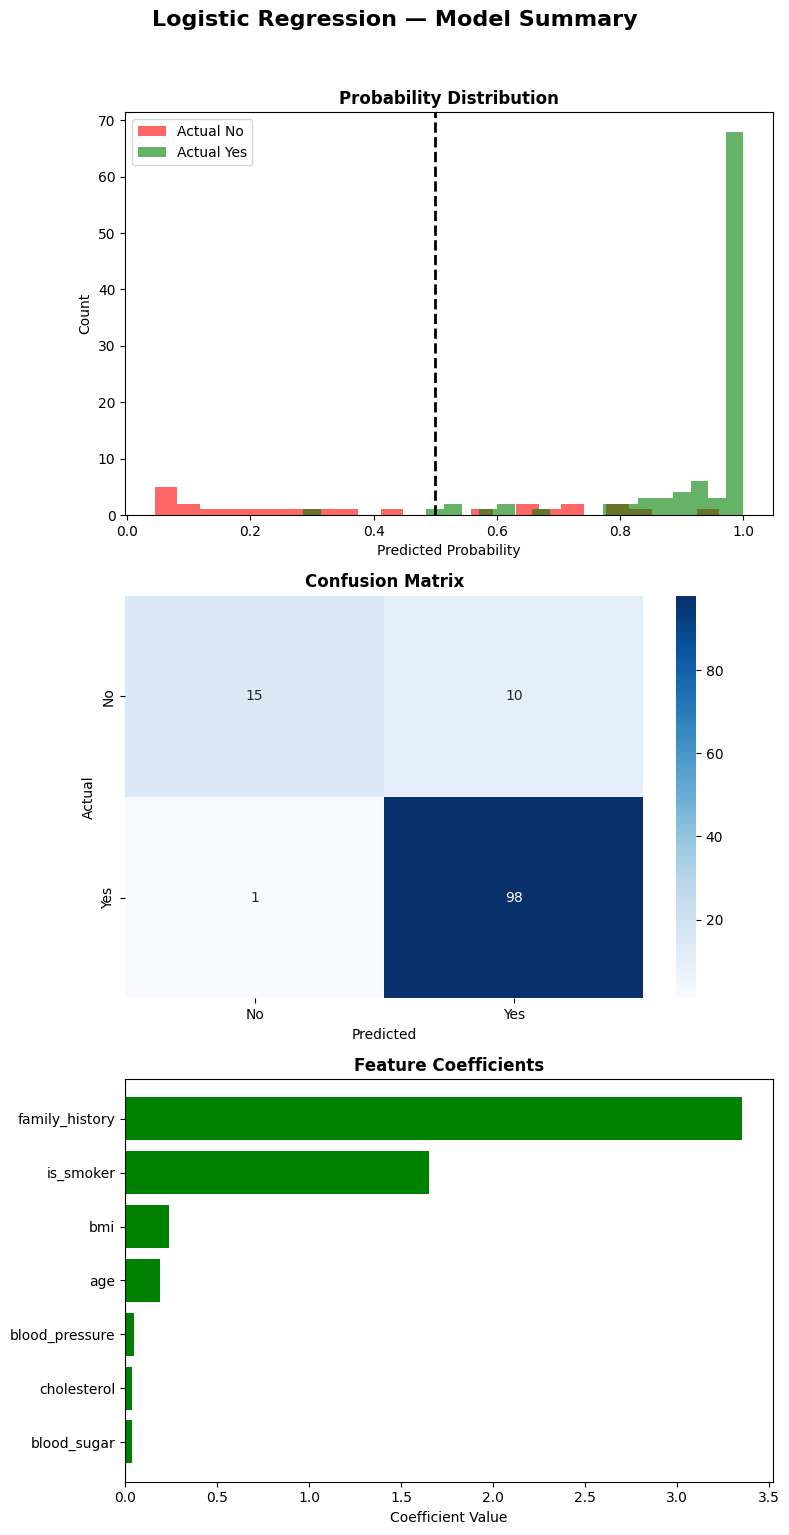

In [107]:
fig, axes = plt.subplots(3, 1, figsize=(8, 15))

# --- Plot 1: Probability Distribution ---
axes[0].hist(y_prob[y_test == 0], bins=25, alpha=0.6,
             color='red', label='Actual No')
axes[0].hist(y_prob[y_test == 1], bins=25, alpha=0.6,
             color='green', label='Actual Yes')
axes[0].axvline(x=0.5, color='black', linestyle='--', linewidth=2)
axes[0].set_title('Probability Distribution', fontweight='bold')
axes[0].set_xlabel('Predicted Probability')
axes[0].set_ylabel('Count')
axes[0].legend()

# --- Plot 2: Confusion Matrix ---
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['No', 'Yes'],
            yticklabels=['No', 'Yes'])
axes[1].set_title('Confusion Matrix', fontweight='bold')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

# --- Plot 3: Feature Coefficients ---
coef_df = pd.DataFrame({
    'Feature':     X.columns,
    'Coefficient': model.coef_[0]
}).sort_values('Coefficient')
colors = ['red' if c < 0 else 'green' for c in coef_df['Coefficient']]
axes[2].barh(coef_df['Feature'], coef_df['Coefficient'], color=colors)
axes[2].axvline(x=0, color='black', linewidth=1.5)
axes[2].set_title('Feature Coefficients', fontweight='bold')
axes[2].set_xlabel('Coefficient Value')

plt.suptitle('Logistic Regression — Model Summary', 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# **For User testing**

In [108]:
def predict_disease():
    try:
        print("🔹 Enter Patient Details:\n")
        
        age = float(input("Age: "))
        bmi = float(input("BMI: "))
        blood_sugar = float(input("Blood Sugar: "))
        blood_pressure = float(input("Blood Pressure: "))
        cholesterol = float(input("Cholesterol: "))
        is_smoker = int(input("Smoker (1 = Yes, 0 = No): "))
        family_history = int(input("Family History (1 = Yes, 0 = No): "))

        user_data = pd.DataFrame([{
        'age': age,
        'bmi': bmi,
        'blood_sugar': blood_sugar,
        'blood_pressure': blood_pressure,
        'cholesterol': cholesterol,
        'is_smoker': is_smoker,
        'family_history': family_history
        }])

        # Prediction
        pred = pipeline.predict(user_data)[0]
        prob = pipeline.predict_proba(user_data)[0][1]

        print("\n🔍 RESULT:")
        print("-" * 30)

        if pred == 1:
            print(f"⚠️ High Risk of Disease")
            print(f"Confidence: {prob*100:.2f}%")
        else:
            print(f"✅ Low Risk of Disease")
            print(f"Confidence: {(1-prob)*100:.2f}%")

        print("-" * 30)

    except Exception as e:
        print("❌ Error:", e)

# Run function
predict_disease()

🔹 Enter Patient Details:


🔍 RESULT:
------------------------------
✅ Low Risk of Disease
Confidence: 65.68%
------------------------------
